# Домашка. MatrixVisualizer (7 баллов)

Кто не понимает контекст, смотрим первый семинар по интерпретации :)
Для выполнения задания РЕКОМЕНДУЕТСЯ пользоваться LLM (с умом!),
    а также посмотреть семинар по bokeh и (дополнительно) HDBSCAN.

Вам нужно написать класс, который визуализирует произвольную матрицу / датафрейм чисел в формате интерактивной heatmap с помощью библиотеки bokeh. Для удобства представим, что на вход приходит матрица размера N_features x K, то есть, своего рода эмбеддинги признаков (например, полученные путем агрегирования инфы из `model.trees_to_dataframe()`). Сами решите, в каком формате вы подаете сами данные (np.ndarray + отдельно лейблы осей Х, Y ✅ или же датафрейм или же что угодно еще). Класс нужно реализовать универсальным образом, то есть не затачиваясь конкретно на то, что вам придут именно признаки, однако в формулировке задания в целях удобочитаемости я буду писать "признаки", где имею в виду строки или же подписи к оси Y. <font color="violet">**подаем np.array, если есть labels к x и y отдельными np.array**</font>

Итак, вам нужно визуализировать матрицу согласно следующим требованиям:
- heatmap-style визуализация (см. семинар) ✅
- Если N_features (в общем случае кол-во строк матрицы) велико, то в первоначальной картинке "признаков" не видно.
      Они должны становиться видны при достаточно крупном зуме (решайте сами каком), чтобы картинка была читаема.
      Соответственно, должен быть реализован механизм зума (через любой инструмент) ✅ <font color="violet">**сделала и на объекты (K), и на фичи (N_features), потому что иногда матрицы огромны!**</font>
- График должен быть раскрашен с помощью QuantileTransformer'a: ✅
```python
a = np.array([1, 2, 0, 4, 10, -1])
b = QT(a, num_quantiles=6)
# b = np.array([0.4, 0.2, 0.6, 0.8, 1., 0.])
```
    (то есть цвета для раскраски формируются по b, а не по a)

- Палитра 'coolwarm'. Должен быть colorbar + числовые подписи к его цветам (хотя бы несколько основных) ✅
- Где-нибудь рядышком должен быть виджет выпадающего окна ✅, в котором можно выбрать, "по какой оси" делать покраску:
    - по строкам (то есть у каждого "признака" свои квантили; вкл. по умолчанию) ✅
    - по столбцам ✅
    - глобальная (то есть, квантиль 1. получает максимальное число в матрице, а 0. -- минимальное) ✅<br>
- После выбора "оси", раскраска должна перерисовываться на лету ✅
- Ваши "признаки" должны быть отсортированы согласно кластеризации HDBSCAN (кормим на вход эмбеддинги "признаков",
      желательно сразу в построчной квантильной форме, которую считали для покраски по умолчанию).
      Не нужно строить иерархии, можно просто отсортировать по номеру кластера ✅ (не забудьте отсортировать и "подписи").
      Нам важно только чтобы похожие "признаки" были рядом. Расположение кластеров относительно друг друга не имеет значения
- Должна быть возможность "выбрать" какие-то признаки (например, инструментом Tap / Выделением),
      после чего они должны появляться в отдельном текстовом окошечке с накинутыми на них кавычками
      и кнопкой Копировать рядом для удобства. ✅
      Это может быть полезно, например, для того, чтобы быстро выкинуть из выборки "признаки", которые вам кажутся
      неудачными при анализе данной матрицы. <font color="violet">**добавила еще и для объектов копировальню, например во втором примере было бы удобно это для выделения кластеров**</font>
- Весь интерактив с виджетами должен быть реализован строго БЕЗ js-коллбэков (можно только для копирования текста в буфер),
    только python-коллбэки с поднятием локального
    bokeh server в ноутбуке (конструкция def app(doc): ... + show(app), см. семинар по bokeh, HDBSCAN) ✅
- Придумайте удобный вам формат принятия данных на вход для того чтобы подписать оси X, Y, (labels, tick_labels) ✅
- Попросите LLM сгенерировать какую-нибудь матрицу, которая наглядно бы демонстрировала, что вы справились с заданием,
      и запустите на ней вашу визуализацию <font color="violet">**синглсел из семинара про dimred**</font>

**! Если у вас в колабе график не будет доступен при открытии ноутбука, я запущу код и все потыкаю, не переживайте!**<br>

Ниже дан ориентир: (там выполнены не все пункты, выполняйте свои)

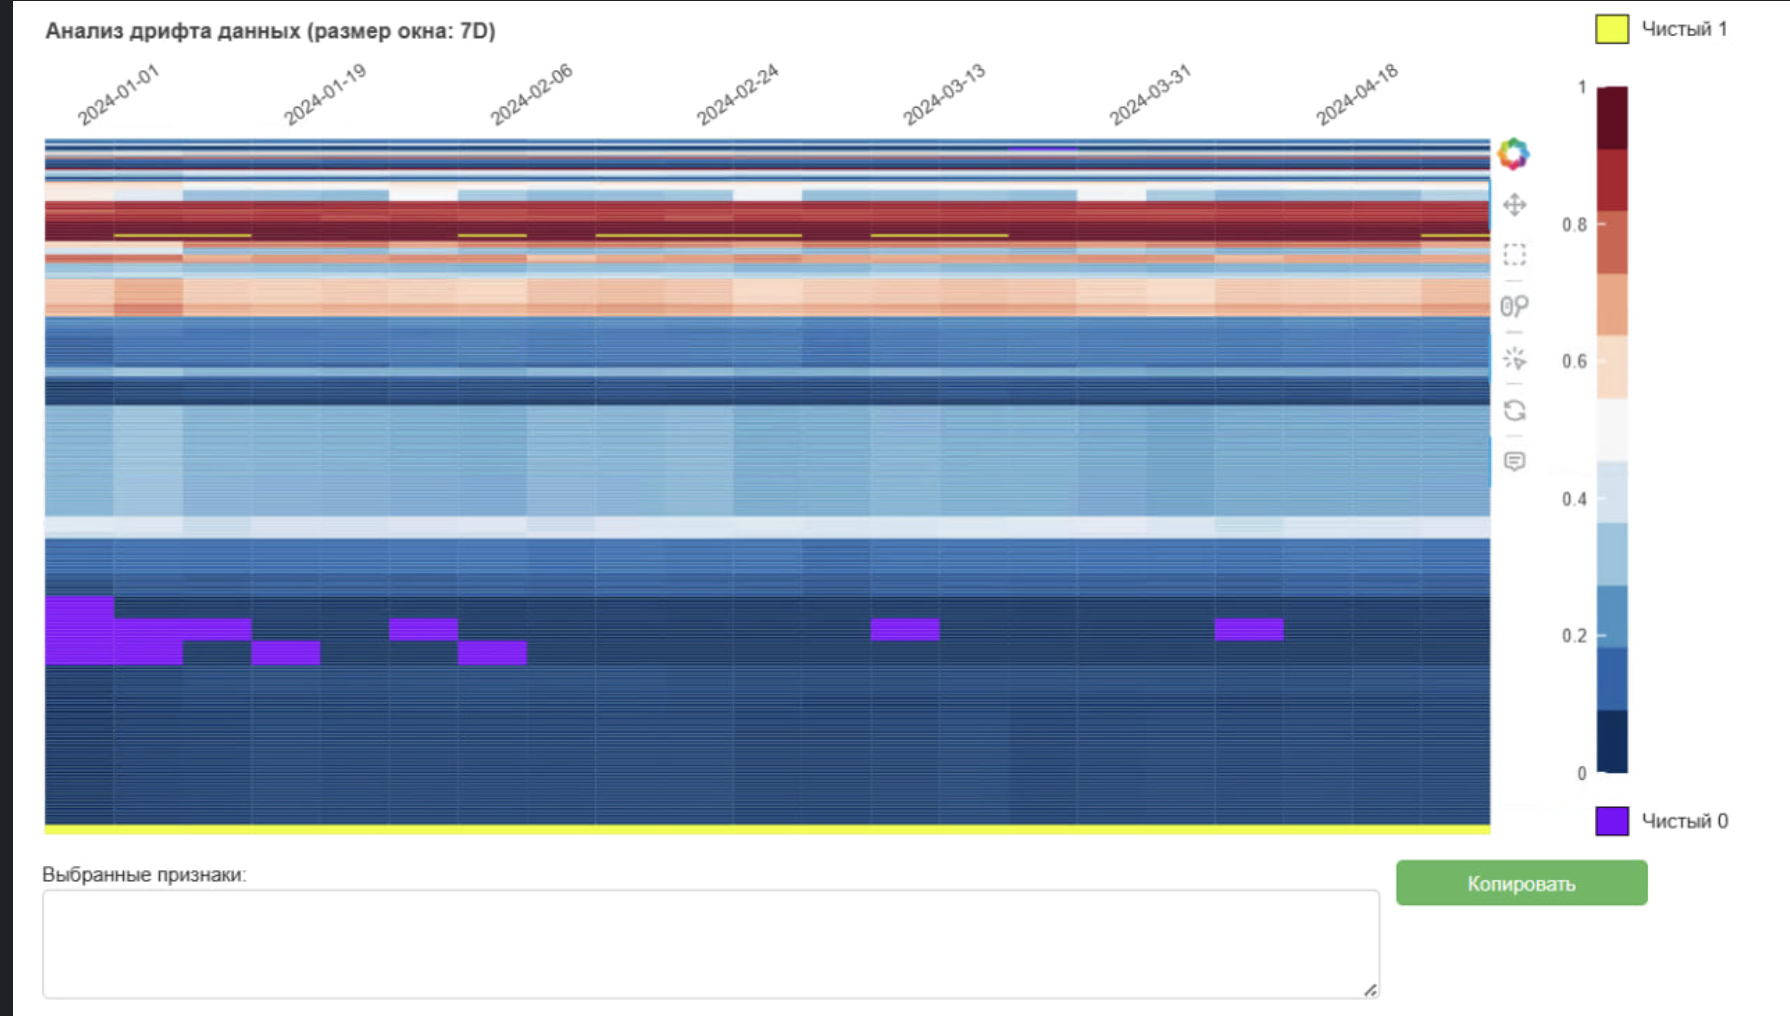

In [28]:
from IPython.display import Image

Image('ex_1.jpg')

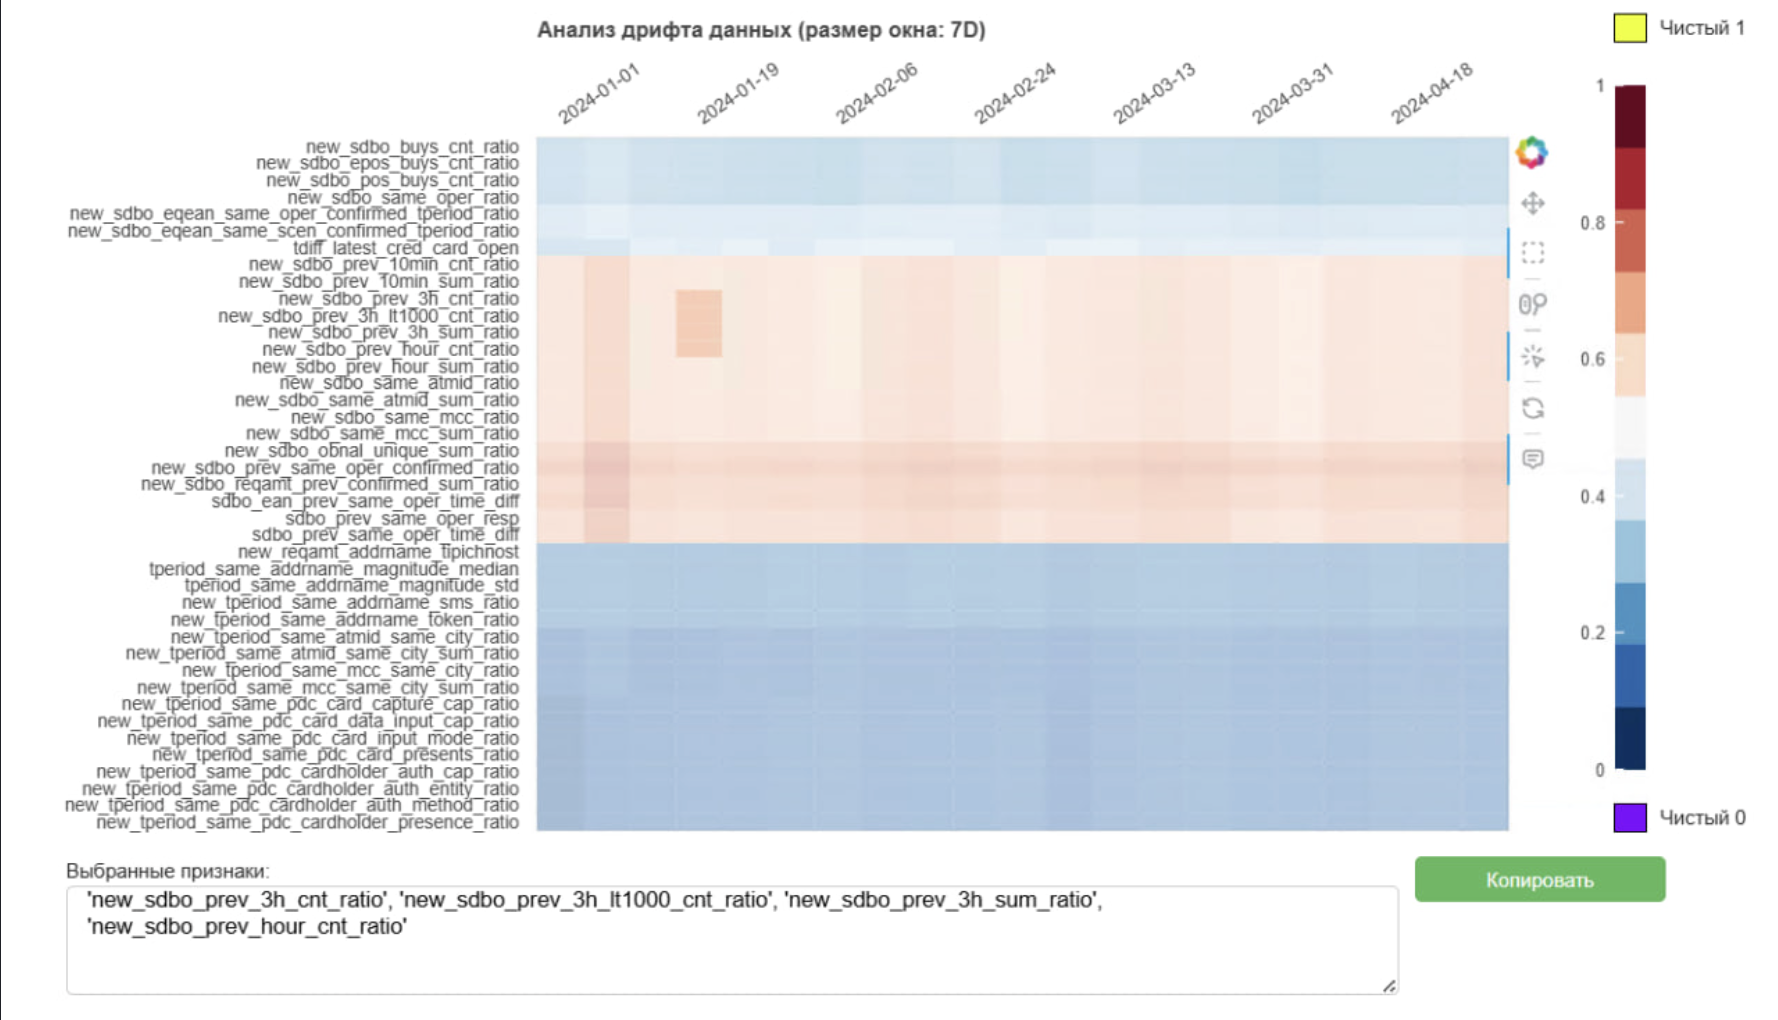

In [29]:
# зум, выделение признаков, появление признаков
Image('ex_2.jpg')

## Удачи!

## спасибо!!

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import sklearn
import bokeh
import hdbscan

import warnings
warnings.filterwarnings("ignore")

from hdbscan import HDBSCAN
from matplotlib import cm

from sklearn.preprocessing import quantile_transform
from bokeh.colors import RGB
from bokeh.io import output_notebook, curdoc
from bokeh.transform import transform
from bokeh.plotting import figure, show
from bokeh.layouts import column, row
from bokeh.models import Div, ColumnDataSource, LinearColorMapper, ColorBar, HoverTool, Dropdown, InlineStyleSheet, Button, TextAreaInput

from bokeh.models.callbacks import CustomJS  # only for copy button

output_notebook()

Loading BokehJS ...

In [2]:
class MatrixVisualizer:
    def __init__(self, 
                 data: np.array, 
                 x_labels: np.array = np.array([None]), 
                 y_labels: np.array = np.array([None]), 
                 x_name: str = None, 
                 y_name: str = None, 
                 z_name: str = None, 
                 title: str = None,
                 min_cluster_size: int = 10, 
                 labels_show_thr: int = 10):
        self.data = data
        self.n_features, self.K = data.shape
        self.y_name = y_name if y_name else 'y'
        self.x_name = x_name if x_name else 'x'
        self.z_name = z_name if z_name else 'value'
        self.y_labels = y_labels if y_labels.all() else np.array([f'y{i}' for i in range(self.n_features)])
        self.x_labels = x_labels if x_labels.all() else np.array([f'x{i}' for i in range(self.K)])
        self.title = title if title else 'heat map'
        self.min_cluster_size = min_cluster_size
        self.labels_show_thr = labels_show_thr

        # make QT for all types of colors
        self.color_by_row, self.color_by_col, self.color_overall = self._QT_transform()

        # now group by row
        indexes = self._order_features()
        self.data = self.data[indexes, :]
        self.color_by_row = self.color_by_row[indexes, :]
        self.color_by_col = self.color_by_col[indexes, :]
        self.color_overall = self.color_overall[indexes, :]
        self.y_labels = self.y_labels[indexes]

        # make ColumnDataSource 
        self.source = ColumnDataSource({
            self.z_name: self.data.reshape(-1),
            'by_row': self.color_by_row.reshape(-1),
            'by_col': self.color_by_col.reshape(-1),
            'overall': self.color_overall.reshape(-1),
            self.x_name: np.tile(self.x_labels, self.n_features),
            self.y_name: np.repeat(self.y_labels, self.K)
            })

        # select a box -> callback -> if all criteria met show them in text box
        self.source.selected.on_change("indices", self.update_selection)

        # text box with features
        selectionbox_style = InlineStyleSheet(css="""
            .bk-input-group label {
                text-align: center !important;
                width: 100% !important;
                display: block !important;
                font-size: 16px !important;  
                font-weight: bold;
            }
            .bk-input {
                color: black !important;
                background-color: white !important;
                font-size: 14px !important;  
            }
            """)
        self.selection = TextAreaInput(title="selected features", value="", width = 700, stylesheets=[selectionbox_style])
        self.selection_x = TextAreaInput(title="selected objects", value="", width = 700, stylesheets=[selectionbox_style])

        # make copy button
        copybutton_colors = InlineStyleSheet(css="""
            .bk-btn {
                font-size: 18px !important;  
                font-weight: bold;
                text-align: center !important;}
                """)
        self.copybutton = Button(label = 'Copy!', width = 75, height = 50, button_type="success", stylesheets=[copybutton_colors])
        self.copybutton_x = Button(label = 'Copy!', width = 75, height = 50, button_type="warning", stylesheets=[copybutton_colors])

        # это сделал гпт
        self.copybutton.js_on_click(
            CustomJS(args=dict(textarea=self.selection), code="""
                navigator.clipboard.writeText(textarea.value);
            """)
            )

        self.copybutton_x.js_on_click(
            CustomJS(args=dict(textarea=self.selection), code="""
                navigator.clipboard.writeText(textarea.value);
            """)
            )
        
        # make color 'coolwarm' (absent in bokeh... had to use matplotlib and convert)
        m_coolwarm_rgb = (255 * cm.coolwarm(range(256))).astype('int')
        coolwarm_palette = [RGB(*tuple(rgb)).to_hex() for rgb in m_coolwarm_rgb]

        # make color mapper
        self.color_mapper = LinearColorMapper(palette=coolwarm_palette, low=0, high=1)

        # make color bar
        color_bar = ColorBar(color_mapper = self.color_mapper, location = (5,6))

        # make hover
        hover = HoverTool(tooltips=[(self.z_name, f"@{self.z_name}")])

        # assign tools
        tools = ["pan", "wheel_zoom","zoom_in","zoom_out","box_zoom","undo","reset","box_select","fullscreen", "tap"]

        # finally make figure
        self.fig = figure(
            x_range=list(self.x_labels),
            y_range=list(self.y_labels),
            tools=tools,
            width=800, height=max(800, self.n_features * 2),
            title=self.title,
            x_axis_label=self.x_name,  
            y_axis_label=self.y_name,  
        )
        self.fig.title.align = "center"
        self.fig.xaxis.axis_label_text_font_size = "14pt"
        self.fig.yaxis.axis_label_text_font_size = "14pt"
        self.fig.title.text_font_size = "18pt"
        self.fig.title.text_font_style = "bold"

        if  self.K <= self.labels_show_thr:
            self.fig.xaxis.visible = True
        else:
            self.fig.xaxis.visible = False

        if self.n_features  <= self.labels_show_thr:
            self.fig.yaxis.visible = True
        else:
            self.fig.yaxis.visible = False

        self.rects = self.fig.rect(
            x=self.x_name,
            y=self.y_name,
            width=1,
            height=1,
            source=self.source,
            fill_color=transform('by_row', self.color_mapper),
            line_color=None
        )
        
        self.fig.add_tools(hover)
        self.fig.add_layout(color_bar, 'right')

        # make dropdowm for colors
        dropdown_colors = InlineStyleSheet(css="""
            .bk-btn {
                font-size: 18px !important;  
                font-weight: bold;
                text-align: center !important;}
            .bk-menu {background-color: #2c3e50;
                    text-align: center !important;
                    width: 100% !important;
                    font-size: 16px !important;}
            .bk-menu-item {color: white; 
                    text-align: center !important;
                    width: 100% !important;
                    font-size: 16px !important}""")
        
        self.dropdown = Dropdown(label="Choose color!", button_type="danger", width=200, menu=[('by row', 'by_row'), ('by column', 'by_col'), ('overall', 'overall')], stylesheets=[dropdown_colors])
        self.dropdown.on_click(self.change_color)

        # Add callback to x_range and y_range
        self.fig.x_range.on_change('end', self.change_labels)
        self.fig.x_range.on_change('start', self.change_labels)
        self.fig.y_range.on_change('end', self.change_labels)
        self.fig.y_range.on_change('start', self.change_labels)

        
    def _QT_transform(self):
        by_row = quantile_transform(self.data, axis=1, n_quantiles=2)
        by_col = quantile_transform(self.data, axis=0, n_quantiles=2)
        overall = quantile_transform(self.data.reshape(-1,1), axis=0, n_quantiles=2).reshape(self.n_features, self.K)
        return by_row, by_col, overall

    def _order_features(self):
        return np.argsort(HDBSCAN(min_cluster_size = self.min_cluster_size).fit_predict(self.color_by_row))

    def change_color(self, event):
        self.rects.glyph.fill_color = transform(event.item, self.color_mapper)

    def update_selection(self, attr, old, new):
        selected_labels = np.unique(self.source.data[self.y_name][new])
        self.selection.value = ', '.join([f"'{label}'" for label in selected_labels])

        selected_labels_x = np.unique(self.source.data[self.x_name][new])
        self.selection_x.value = ', '.join([f"'{label}'" for label in selected_labels_x])
        return

    def change_labels(self, attr, old, new):
        if self.fig.x_range.end - self.fig.x_range.start <= self.labels_show_thr:
            self.fig.xaxis.visible = True
        else:
            self.fig.xaxis.visible = False

        if self.fig.y_range.end - self.fig.y_range.start <= self.labels_show_thr:
            self.fig.yaxis.visible = True
        else:
            self.fig.yaxis.visible = False

    def layout(self):
        return column(row(self.dropdown, align='center'), self.fig, row(self.selection, self.copybutton), row(self.selection_x, self.copybutton_x))
        

#### минимальный пример того, что в принципе все работает

In [21]:
def app(doc):
    viz = MatrixVisualizer(100*np.random.randn(20, 5))
    doc.add_root(viz.layout())

show(app)

#### ну раз мои примеры не подходят)) возьмем sklearn датасет для кластеризации

In [22]:
# возьмем датасет про который знаем что в нем 6 кластеров
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=6, n_features=20, random_state=57)

def app(doc):
    viz = MatrixVisualizer(X)
    doc.add_root(viz.layout())

show(app)

#### био данные <3

In [ ]:
# извините, очень не люблю llm и не вижу смысла проверять визуализацию на рандомных данных.
# давайте посмотрим что нибудь реально классное, что 1) точно группируется по hdbscan; 2) позволяет большую матрицу нарисовать

In [23]:
# из семинара про dimred есть данные синглсела
# будет какое-то время грузиться

import urllib
import io

with urllib.request.urlopen("https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/expression_data.npz") as response:
    file_bytes = io.BytesIO(response.read())
    
data = sp.sparse.load_npz(file_bytes).toarray().astype("float32")
meta_row = pd.read_parquet('https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_row.parquet ')
meta_col = pd.read_parquet('https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_col.parquet')

data.shape, meta_row.shape, meta_col.shape

((50753, 1000), (50753, 4), (1000, 2))

In [10]:
# 50k x 1k он конечно не будет показывать) так что обрубим данные
# возьмем 100 генов (Ox) и 500 маркеров (Oy)

# каждый ген описан экспрессионным вектором с разными маркерами. группируем, теперь использованные нами маркеры скластеризованы

# выделяем какую-нибудь ярко красную полоску, в features получаем маркеры, а в objects соотв ген)

In [24]:
def app(doc):
    viz = MatrixVisualizer(data[:500, :100] ,meta_col.index[:100], meta_row.index[:500], 'genes', 'markers', 'z_score', 'single cell')
    doc.add_root(viz.layout())

show(app)

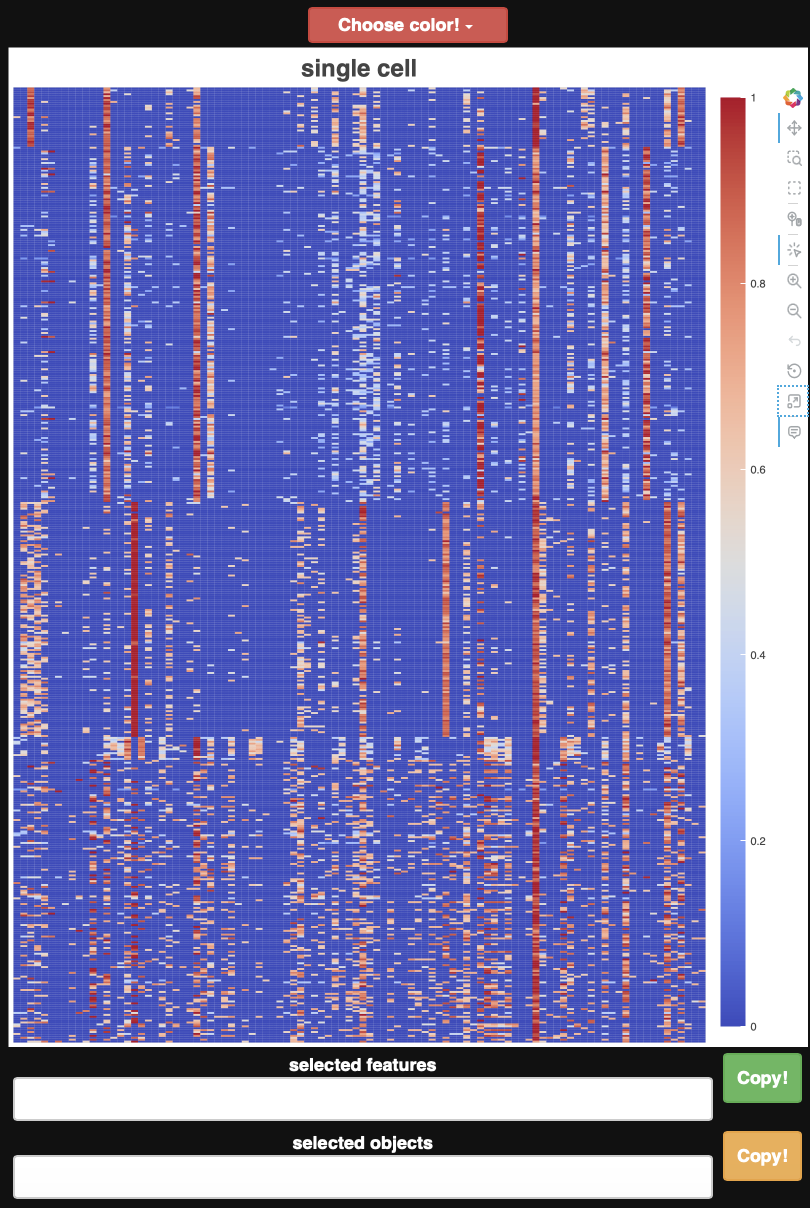

In [6]:
# если лень запускать, то вот как оно выглядит
Image('proof.png')